# 3. Georeferencing

The package has two methods to compute the latitude and longitude of every pixel:

| | `processing.project` | `georef_paulr` |
|---|---|---|
| view directions | one set of calibrated viewing angles for all channels | per-pixel calibration of each channel |
| channel alignment | not considered | boresight offsets per channel and campaign |
| surface | flat, at sea level | plane at `ref_height` above the WGS84 ellipsoid, found iteratively |
| extra dependency | -- | [`mounttree`](https://pypi.org/project/mounttree/) |

`campaign.georef` runs either one on a time slice. `georef_paulr.georef_frame` and `georef_paulr.georef_series` work with any navigation data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from velox_tools import campaign, georef_paulr

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def distance(lat1, lon1, lat2, lon2):
    """Great-circle distance (m)."""
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(v, dtype=float)) for v in (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371e3 * np.arcsin(np.sqrt(a))

## A single frame

`georef_frame` needs the aircraft position and attitude at the frame time. With `footprint=True`, the result is on the 635 x 507 grid of the final images; otherwise it is on the 640 x 512 grid of the sensor.

In [2]:
t = slice('2024-08-25T12:30:00', '2024-08-25T12:30:09')
ds = campaign.load_velox(t, channels=3)
nav = campaign.interp_nav(campaign.load_nav(t), ds.time)
n0 = nav.isel(time=0)
aircraft = dict(lat=float(n0['lat']), lon=float(n0['lon']), height=float(n0['alt']),
                roll=float(n0['roll']), pitch=float(n0['pitch']), yaw=float(n0['hdg']))

frame = georef_paulr.georef_frame(**aircraft, channel=3, campaign='PERCUSION', footprint=True)
frame

<xarray.Dataset> Size: 8MB
Dimensions:  (x-pixel: 635, y-pixel: 507)
Coordinates:
  * x-pixel  (x-pixel) int64 5kB 0 1 2 3 4 5 6 7 ... 628 629 630 631 632 633 634
  * y-pixel  (y-pixel) int64 4kB 0 1 2 3 4 5 6 7 ... 500 501 502 503 504 505 506
Data variables:
    lat      (x-pixel, y-pixel) float64 3MB 5.151 5.151 5.15 ... 5.047 5.047
    lon      (x-pixel, y-pixel) float64 3MB -33.07 -33.07 -33.07 ... -33.1 -33.1
    height   (x-pixel, y-pixel) float64 3MB 6.407e-07 6.342e-07 ... 2.971e-07
Attributes:
    description:  Georeferenced VELOX pixels (mounttree/PaulR method)
    ref_height:   0.0
    channel:      3
    campaign:     PERCUSION

In [3]:
across = distance(frame.lat[0, 253], frame.lon[0, 253], frame.lat[-1, 253], frame.lon[-1, 253])
along = distance(frame.lat[317, 0], frame.lon[317, 0], frame.lat[317, -1], frame.lon[317, -1])
print(f'frame footprint at {aircraft["height"]:.0f} m altitude: {across / 1e3:.1f} km x {along / 1e3:.1f} km')

frame footprint at 13895 m altitude: 9.0 km x 7.1 km


## A series of frames

`campaign.georef` returns the brightness temperatures of one channel together with `lats`/`lons` per pixel. Drawn on a map, consecutive frames line up:

In [4]:
geo = campaign.georef(t, channel=3)
geo

<xarray.Dataset> Size: 90MB
Dimensions:    (time: 10, x: 635, y: 507)
Coordinates:
  * time       (time) datetime64[ns] 80B 2024-08-25T12:30:00.306000 ... 2024-...
    band       int64 8B 3
  * x          (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y          (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    BT_2D      (time, x, y) float32 13MB dask.array<chunksize=(10, 635, 507), meta=np.ndarray>
    BT_Center  (time) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    lats       (time, x, y) float64 26MB 5.151 5.151 5.15 ... 5.04 5.04 5.04
    lons       (time, x, y) float64 26MB -33.07 -33.07 -33.07 ... -33.12 -33.12
    height     (time, x, y) float64 26MB 6.407e-07 6.342e-07 ... 2.617e-07
Attributes:
    campaign:         PERCUSION
    research_flight:  RF07

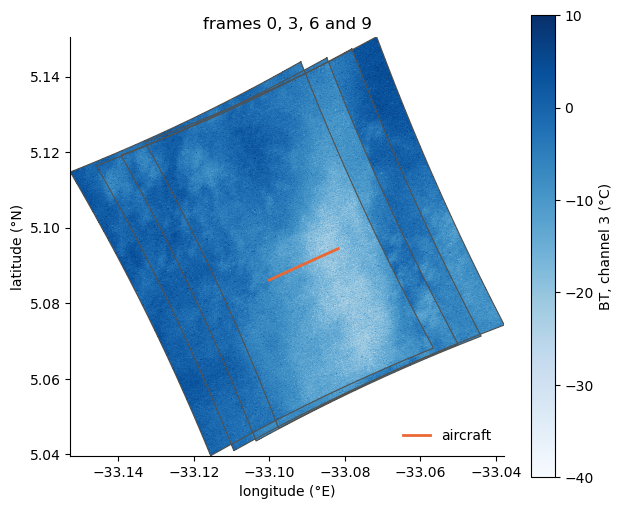

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for i in [0, 3, 6, 9]:
    f = geo.isel(time=i)
    m = ax.pcolormesh(f['lons'][::2, ::2], f['lats'][::2, ::2], f['BT_2D'][::2, ::2][:-1, :-1],
                      cmap='Blues', vmin=-40, vmax=10, rasterized=True)
    edge = np.concatenate([f['lons'][0, :], f['lons'][:, -1], f['lons'][-1, ::-1], f['lons'][::-1, 0]]), \
        np.concatenate([f['lats'][0, :], f['lats'][:, -1], f['lats'][-1, ::-1], f['lats'][::-1, 0]])
    ax.plot(*edge, color='#52514e', linewidth=0.8)
ax.plot(nav['lon'], nav['lat'], color='#eb6834', linewidth=2, label='aircraft')
fig.colorbar(m, label='BT, channel 3 (°C)')
ax.set(xlabel='longitude (°E)', ylabel='latitude (°N)', aspect='equal', title='frames 0, 3, 6 and 9')
ax.legend(frameon=False, loc='lower right');

## The channels look in slightly different directions

Every channel has its own boresight offset angles. The final images are already aligned by a few pixels per channel; the georeferencing accounts for what remains. Distance of the centre pixel of each channel from that of channel 3, for the same aircraft position:

In [6]:
offsets = {}
for channel in campaign.CHANNELS:
    f = georef_paulr.georef_frame(**aircraft, channel=channel, campaign='PERCUSION', footprint=True)
    offsets[channel] = distance(f.lat[317, 253], f.lon[317, 253], frame.lat[317, 253], frame.lon[317, 253])
pd.Series(offsets, name='offset from channel 3 (m)').rename_axis('channel').round(1).to_frame()

,offset from channel 3 (m)
channel,
1,61.8
2,63.3
3,0.0
5,72.4
6,56.4


Calibrations exist for both campaigns:

In [7]:
georef_paulr.available_channels('PERCUSION')

['Channel1', 'Channel2', 'Channel3', 'Channel5', 'Channel6']

## Comparison with `processing.project`

`method='project'` uses the same viewing angles for all channels and ignores the boresight offsets. The two methods differ by:

100%|██████████| 10/10 [00:05<00:00,  1.72it/s]


median 346 m, 95th percentile 430 m


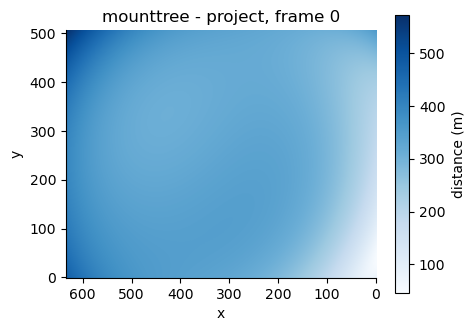

In [8]:
proj = campaign.georef(t, channel=3, method='project')
d = distance(geo['lats'], geo['lons'], proj['lats'], proj['lons'])
print(f'median {np.median(d):.0f} m, 95th percentile {np.percentile(d, 95):.0f} m')

fig, ax = plt.subplots(figsize=(5, 3.6))
m = ax.imshow(d[0].T, origin='lower', cmap='Blues')
ax.invert_xaxis()
ax.set(xlabel='x', ylabel='y', title='mounttree - project, frame 0')
fig.colorbar(m, label='distance (m)');

## Cloud-top height

By default, pixels are projected onto sea level. For clouds, pass the cloud-top height as `ref_height`; otherwise their positions are displaced away from the nadir point. For a cloud top at 10 km, seen from about 14 km:

In [9]:
high = georef_paulr.georef_frame(**aircraft, channel=3, campaign='PERCUSION', footprint=True, ref_height=10000)
shift = distance(frame.lat, frame.lon, high.lat, high.lon)
print(f'centre pixel moves by {float(shift[317, 253]):.0f} m, the frame corners by {float(shift[0, 0]) / 1e3:.1f} km')

centre pixel moves by 374 m, the frame corners by 4.6 km


## Validation with coastal edges

A coastline provides an independent check: the land–water boundary in the thermal image should follow the reference shoreline after georeferencing. Compare both methods on the **same frame and channel**, first inspecting the image without an overlay so the reference line does not hide an offset.

The presets below have VELOX data at coastal crossings: Svalbard during HALO-(AC)³, and Cape Verde or Barbados during PERCUSION. The Svalbard example shows a clear boundary; the tropical examples are partly obscured and need careful screening before measuring anything. Change `site`, `coast_time`, or `coast_channel` to inspect another crossing or neighbouring frames. Start with one frame: HALO-(AC)³ archive chunking can decompress about 3 GB per channel.

**Use detailed shorelines.** Natural Earth's `10m` coastline is a generalized **1:10 million** map, not 10 metre data; its long straight segments are unsuitable here. This section uses:

| Region | Reference |
|---|---|
| Svalbard | Norwegian Polar Institute [S100 map data](https://data.npolar.no/geodata), `S100_Land_l`, selecting only `Kystkontur` (coastline); map data © Norwegian Polar Institute, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |
| Cape Verde / Barbados | [GSHHG 2.3.7](https://www.soest.hawaii.edu/pwessel/gshhg/), **full** resolution, level 1 land–ocean boundaries |

Install the optional plotting dependencies with `%pip install cartopy pyproj`. On first use, the selected reference archive is downloaded from its provider into `coast_cache` (S100: about 290 MB; GSHHG: about 149 MB). Further runs use the cache. For offline use, put the archive there in advance, or set `coastline_path` to a local shoreline shapefile with its `.prj`. The cache defaults to the system temporary directory; change it to retain downloads permanently. Coordinates are transformed from the reference CRS; no line simplification or smoothing is applied.

More detail does not guarantee metre-level accuracy. Check the shoreline's survey date and uncertainty, especially around changing glacier fronts. GSHHG is an older global compilation. For precise calibration, use stable coastal stretches and a contemporaneous surveyed shoreline or orthophoto with known geolocation accuracy.

In [10]:
from pathlib import Path
import shutil
import tempfile
from urllib.request import urlopen
from zipfile import ZipFile

from cartopy.io import shapereader
from pyproj import CRS, Transformer
from shapely.geometry import Point, box
from shapely.ops import transform, unary_union

coastal_examples = {
    'Svalbard': '2022-04-04T09:03:31',       # HALO-(AC)³ RF13
    'Cape Verde': '2024-08-11T19:13:44',     # PERCUSION RF01
    'Barbados': '2024-09-23T12:26:03',       # PERCUSION RF20
}
site = 'Svalbard'
coast_time = pd.Timestamp(coastal_examples[site])  # UTC
coast_channel = 3
coast_ref_height = 0.0  # metres above WGS84 ellipsoid; adjust to local sea-surface height
coast_cache = Path(tempfile.gettempdir()) / 'pyvelox-coastlines'
coastline_path = None  # local shoreline shapefile with .prj; skips downloading


def cached_shoreline(url, member):
    """Download once, then extract the selected shapefile and provider license files."""
    coast_cache.mkdir(parents=True, exist_ok=True)
    archive = coast_cache / url.rsplit('/', 1)[-1]
    if not archive.exists():
        print(f'Downloading {url}')
        partial = archive.with_suffix('.zip.part')
        with urlopen(url, timeout=120) as response, partial.open('wb') as output:
            shutil.copyfileobj(response, output)
        partial.replace(archive)
    target = coast_cache / member
    with ZipFile(archive) as zipped:
        for name in zipped.namelist():
            item = Path(name)
            if item.stem == Path(member).stem or any(
                    word in item.name.lower() for word in ('license', 'licence', 'copying', 'readme')):
                # Use only safe relative archive paths, preserving the provider's license.
                if item.is_absolute() or '..' in item.parts:
                    raise ValueError(f'Unexpected archive member: {name}')
                if not (coast_cache / item).exists():
                    zipped.extract(name, coast_cache)
    if not target.exists():
        raise FileNotFoundError(f'{member} not found in {archive}')
    return target


coast_is_npi = coastline_path is None and site == 'Svalbard'
if coastline_path is None:
    if coast_is_npi:
        coastline_path = cached_shoreline(
            'https://publicdata.npolar.no/kartdata/NP_S100_SHP.zip',
            'NP_S100_SHP/S100_Land_l.shp')
        coast_source = 'NPI S100 • © Norwegian Polar Institute (CC BY 4.0)'
    else:
        coastline_path = cached_shoreline(
            'https://ftp.soest.hawaii.edu/gshhg/gshhg-shp-2.3.7.zip',
            'GSHHS_shp/f/GSHHS_f_L1.shp')
        coast_source = 'GSHHG 2.3.7 • full resolution, level 1'
else:
    coast_source = f'Local reference: {Path(coastline_path).name}'
coastline_path = Path(coastline_path)
source_crs = CRS.from_wkt(coastline_path.with_suffix('.prj').read_text())
print(f'{site}: {campaign.flight(coast_time)}, {coast_time} UTC, channel {coast_channel}')
print(f'Reference: {coast_source}\n{coastline_path}')

Svalbard: ('HALO-AC3', 'RF13'), 2022-04-04 09:03:31 UTC, channel 3
Reference: NPI S100 • © Norwegian Polar Institute (CC BY 4.0)
/projekt_agmwend/home_rad/Joshua/tmp/pyvelox-coastlines/NP_S100_SHP/S100_Land_l.shp


### Load one coastal frame

Use the first available exposure within the selected second, then interpolate navigation to its actual timestamp. Both methods reuse the loaded image. `ref_height=0` is the WGS84 ellipsoid in `georef_paulr`; local mean sea level can differ from it. For a precise check, use the local sea-surface ellipsoidal height. `processing.project` retains its own sea-level approximation.

In [11]:
from velox_tools import processing

coast_window = slice(coast_time, coast_time + pd.Timedelta(seconds=1) - pd.Timedelta(nanoseconds=1))
coast_ds = campaign.load_velox(coast_window, channels=coast_channel).isel(band=0)
if coast_ds.sizes['time'] == 0:
    raise ValueError('No VELOX exposure in this second; choose a nearby coast_time.')
coast_ds = coast_ds.isel(time=slice(0, 1)).load()
coast_nav = campaign.interp_nav(campaign.load_nav(coast_time), coast_ds.time)
if not all(np.isfinite(coast_nav[key]).all() for key in ('lat', 'lon', 'alt', 'roll', 'pitch', 'hdg')):
    raise ValueError('Missing navigation at the exposure time; choose another frame.')

coast_calibrated = georef_paulr.georef_series(
    coast_nav, channel=coast_channel, campaign=coast_ds.attrs['campaign'],
    footprint=True, ref_height=coast_ref_height,
).rename({'x-pixel': 'x', 'y-pixel': 'y', 'lat': 'lats', 'lon': 'lons'})
coast_project = processing.project(coast_ds, nav_data=coast_nav)
coast_geometries = {'georef_paulr': coast_calibrated, 'processing.project': coast_project}
coast_bt = coast_ds['BT_2D'].isel(time=0).transpose('x', 'y').values
print(f'Exposure: {pd.Timestamp(coast_ds.time.values[0])} UTC')
print(f'Altitude: {float(coast_nav.alt.values[0]):.0f} m; roll: {float(coast_nav["roll"].values[0]):.2f}°')

100%|██████████| 1/1 [00:00<00:00,  1.78it/s]

Exposure: 2022-04-04 09:03:31 UTC
Altitude: 11843 m; roll: 0.08°


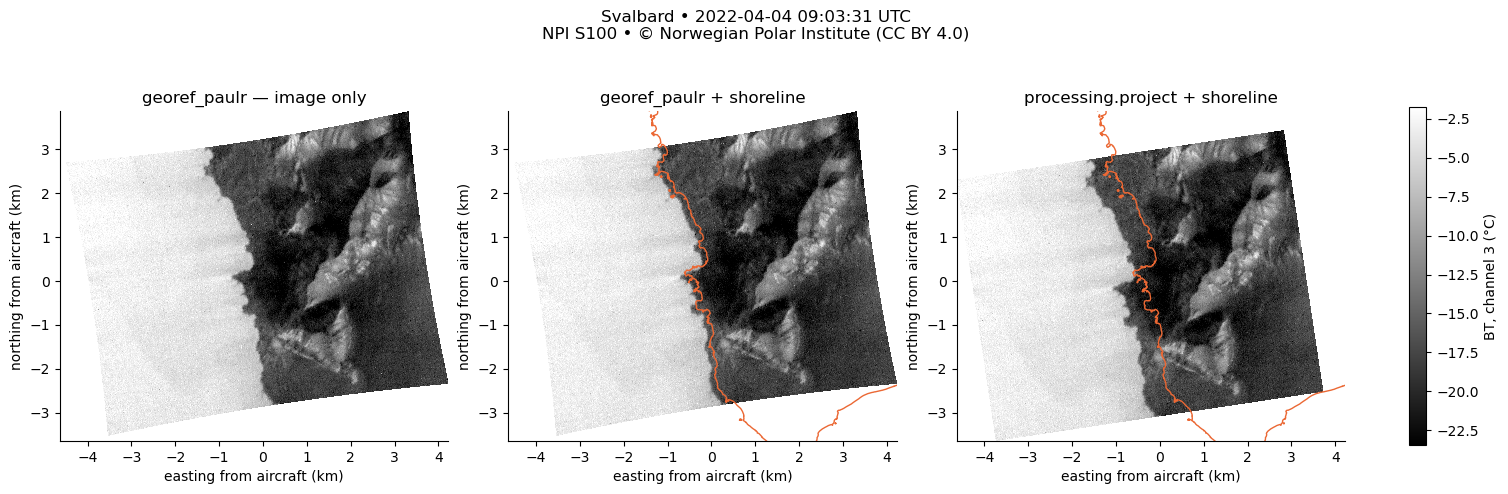

In [12]:
# A local metric projection keeps the Arctic and tropical maps equally readable.
coast_crs = CRS.from_proj4(
    f'+proj=aeqd +lat_0={float(coast_nav.lat.values[0])} '
    f'+lon_0={float(coast_nav.lon.values[0])} +datum=WGS84 +units=m')
coast_transform = Transformer.from_crs('EPSG:4326', coast_crs, always_xy=True).transform
coast_xy = {}
for method, geometry in coast_geometries.items():
    lon = geometry['lons'].isel(time=0).transpose('x', 'y').values
    lat = geometry['lats'].isel(time=0).transpose('x', 'y').values
    if not (np.isfinite(lon).all() and np.isfinite(lat).all()):
        raise ValueError(f'{method}: non-finite pixel coordinates; choose another frame.')
    coast_xy[method] = coast_transform(lon, lat)

# Clip before projecting, retaining line segments rather than only coastline vertices.
all_lon = np.concatenate([g['lons'].values.ravel() for g in coast_geometries.values()])
all_lat = np.concatenate([g['lats'].values.ravel() for g in coast_geometries.values()])
coast_box = box(all_lon.min() - 0.05, all_lat.min() - 0.05,
                all_lon.max() + 0.05, all_lat.max() + 0.05)
to_source = Transformer.from_crs('EPSG:4326', source_crs, always_xy=True)
to_lonlat = Transformer.from_crs(source_crs, 'EPSG:4326', always_xy=True).transform
native_bounds = to_source.transform_bounds(*coast_box.bounds)
reader = shapereader.Reader(str(coastline_path), bbox=native_bounds)
coast_parts = []
for record in reader.records():
    if coast_is_npi and record.attributes.get('OBJTYPE') != 'Kystkontur':
        continue  # exclude artificial data limits and river/lake closing lines
    geometry = record.geometry
    if geometry.geom_type in ('Polygon', 'MultiPolygon'):
        geometry = geometry.boundary  # BEFORE clipping: no artificial box edges
    geometry = transform(to_lonlat, geometry)
    if geometry.intersects(coast_box):
        coast_parts.append(geometry.intersection(coast_box))
reader.close()
if not coast_parts:
    raise ValueError('No reference shoreline near this frame; choose another coast_time or reference.')
coast_reference = transform(coast_transform, unary_union(coast_parts))


def coast_lines(geometry):
    if geometry.geom_type in ('LineString', 'LinearRing'):
        yield geometry
    elif hasattr(geometry, 'geoms'):
        for part in geometry.geoms:
            yield from coast_lines(part)


coast_reference_lines = list(coast_lines(coast_reference))
if not coast_reference_lines:
    raise ValueError('The reference must contain shoreline lines or land polygons.')
coast_reference = unary_union(coast_reference_lines)
finite_bt = coast_bt[np.isfinite(coast_bt)]
if finite_bt.size == 0:
    raise ValueError('No finite brightness temperatures in this frame.')
coast_limits = np.percentile(finite_bt, [2, 98])


def pixel_corners(centres):
    """Interpolate corners and extrapolate the outer half-pixel for a rotated grid."""
    padded = np.pad(centres, 1, mode='edge')
    padded[0, 1:-1] = 2 * centres[0] - centres[1]
    padded[-1, 1:-1] = 2 * centres[-1] - centres[-2]
    padded[:, 0] = 2 * padded[:, 1] - padded[:, 2]
    padded[:, -1] = 2 * padded[:, -2] - padded[:, -3]
    return (padded[:-1, :-1] + padded[1:, :-1]
            + padded[:-1, 1:] + padded[1:, 1:]) / 4

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
for ax, method, overlay in zip(
        axes, ['georef_paulr', 'georef_paulr', 'processing.project'], [False, True, True]):
    east, north = coast_xy[method]
    mesh = ax.pcolormesh(pixel_corners(east) / 1000, pixel_corners(north) / 1000, coast_bt, shading='flat',
                         cmap='gray', vmin=coast_limits[0], vmax=coast_limits[1], rasterized=True)
    if overlay:
        for line in coast_reference_lines:
            x, y = line.xy
            ax.plot(np.asarray(x) / 1000, np.asarray(y) / 1000, color='#eb6834', lw=1)
    # Use the same extent for both methods; do not let the reference expand the axes.
    all_east = np.concatenate([xy[0].ravel() for xy in coast_xy.values()]) / 1000
    all_north = np.concatenate([xy[1].ravel() for xy in coast_xy.values()]) / 1000
    ax.set(xlim=(all_east.min(), all_east.max()), ylim=(all_north.min(), all_north.max()),
           xlabel='easting from aircraft (km)', ylabel='northing from aircraft (km)',
           aspect='equal', title=method + (' + shoreline' if overlay else ' — image only'))
fig.colorbar(mesh, ax=axes, label=f'BT, channel {coast_channel} (°C)', shrink=0.75)
fig.suptitle(f'{site} • {pd.Timestamp(coast_ds.time.values[0])} UTC\n{coast_source}');

### Interactively measure land–water edge pixels

Identify an unambiguous surface shoreline in the image before selecting points. Reject cloud edges, cloud shadows, sea-ice edges and glacier fronts; at Svalbard, sea ice can obscure the actual shoreline. Repeat the check on neighbouring frames, different coast orientations and channels. A consistent displacement suggests checking timing, attitude, boresight and reference height; an isolated displaced thermal edge may not be a shoreline.

Install the interactive dependencies once with `%pip install ipympl ipywidgets` (restart the kernel after installation if needed). Run the cell below in a live Jupyter notebook, then **left-click a shoreline pixel** in the detector image. Each click snaps to the nearest pixel centre and adds a cyan marker; both methods' distances and summary statistics update immediately. Use **Undo last point** or **Clear points** to correct a selection. Zoom or pan with the figure toolbar, then turn that tool off before selecting; clicks during zoom/pan are ignored. Selecting the same pixel twice does not duplicate it. Rerunning the picker cell starts a fresh selection for the current frame. Static HTML/PDF notebook exports cannot accept clicks.

The detector view gives the original `(x, y)` indices. The table measures each georeferenced pixel centre's **unsigned shortest distance to the reference line**, in metres, for both methods. These are cross-shore discrepancies, not full position errors or a calibration fit. They include pixel selection, reference-map, tidal and height uncertainty. The reference must be accurate enough for the desired pixel-scale assessment; no pass/fail threshold is assumed, and an empty selection produces no accuracy claim.

In [16]:
import ipywidgets as widgets
from IPython.display import display

get_ipython().run_line_magic('matplotlib', 'widget')


class CoastalPointPicker:
    """Click image pixels and measure their distance to the independent shoreline."""

    def __init__(self, bt, xy, reference, limits, title):
        self.bt, self.xy, self.reference = bt, xy, reference
        self.pixels = []
        self.residuals = pd.DataFrame(columns=['x', 'y', *xy])
        self.results = widgets.HTML()
        self.undo_button = widgets.Button(description='Undo last point', disabled=True)
        self.clear_button = widgets.Button(description='Clear points', disabled=True)
        self.undo_button.on_click(self.undo)
        self.clear_button.on_click(self.clear)
        # Display the canvas inside the widget only once.
        with plt.ioff():
            self.fig, self.ax = plt.subplots(figsize=(8, 6), layout='constrained')
        self.ax.imshow(bt.T, origin='lower', cmap='gray', vmin=limits[0], vmax=limits[1])
        self.ax.invert_xaxis()
        self.ax.set(xlabel='x pixel', ylabel='y pixel (flight direction)', title=title)
        self.markers = self.ax.scatter([], [], s=65, facecolors='none', edgecolors='cyan', linewidths=1.5)
        self.click_id = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
        self.ui = widgets.VBox([
            widgets.HTML('<b>Left-click surface shoreline pixels.</b> Turn off zoom/pan to select.'),
            self.fig.canvas,
            widgets.HBox([self.undo_button, self.clear_button]),
            self.results,
        ])
        self.refresh()

    def on_click(self, event):
        toolbar = self.fig.canvas.toolbar
        if (event.inaxes is not self.ax or event.button != 1
                or (toolbar is not None and toolbar.mode)
                or event.xdata is None or event.ydata is None):
            return
        if not np.isfinite([event.xdata, event.ydata]).all():
            return
        x, y = np.floor(np.array([event.xdata, event.ydata]) + 0.5).astype(int)
        if not (0 <= x < self.bt.shape[0] and 0 <= y < self.bt.shape[1]):
            return
        if not np.isfinite(self.bt[x, y]) or (x, y) in self.pixels:
            return
        self.pixels.append((int(x), int(y)))
        self.refresh()

    def undo(self, _=None):
        if self.pixels:
            self.pixels.pop()
        self.refresh()

    def clear(self, _=None):
        self.pixels.clear()
        self.refresh()

    def refresh(self):
        self.markers.set_offsets(np.asarray(self.pixels, dtype=float).reshape(-1, 2))
        self.undo_button.disabled = self.clear_button.disabled = not self.pixels
        self.residuals = pd.DataFrame(self.pixels, columns=['x', 'y'])
        for method, (east, north) in self.xy.items():
            self.residuals[method] = [
                Point(east[x, y], north[x, y]).distance(self.reference)
                for x, y in self.pixels]
        if self.pixels:
            summary = self.residuals[list(self.xy)].agg(['median', 'max'])
            summary.loc['95th percentile'] = self.residuals[list(self.xy)].quantile(0.95)
            self.results.value = (
                f'<b>{len(self.pixels)} selected shoreline pixel(s); distances in metres</b>'
                + self.residuals.round(1).to_html(index=False)
                + summary.loc[['median', '95th percentile', 'max']].round(1).to_html()
            )
        else:
            self.results.value = 'No shoreline pixels selected; click the image to measure.'
        self.fig.canvas.draw_idle()

    def close(self):
        self.fig.canvas.mpl_disconnect(self.click_id)
        self.undo_button.on_click(self.undo, remove=True)
        self.clear_button.on_click(self.clear, remove=True)
        plt.close(self.fig)
        for widget in (self.undo_button, self.clear_button, self.results, self.ui):
            widget.close()


# Disconnect the previous picker when rerunning this cell or changing frames.
if 'coast_picker' in globals():
    coast_picker.close()
coast_picker = CoastalPointPicker(
    coast_bt, coast_xy, coast_reference, coast_limits,
    f'{site} • {pd.Timestamp(coast_ds.time.values[0])} UTC • channel {coast_channel}')
display(coast_picker.ui)

In [19]:
# The live selection is always available as coast_picker.pixels and coast_picker.residuals.
# Run this cell after selecting points to take a snapshot for further analysis/export.
coastal_pixels = coast_picker.pixels.copy()
coast_residuals = coast_picker.residuals.copy()
if coastal_pixels:
    display(coast_residuals.round(1))
else:
    print('Click shoreline pixels in the interactive image above to measure their offsets.')
coast_residuals.to_csv('halo-ac3_shoreline_discrepancies.csv', index=False)

,x,y,georef_paulr,processing.project
0,366,260,80.2,510.4
1,330,262,89.8,106.6
2,349,197,30.9,438.8
3,356,183,135.9,583.6
4,341,104,123.5,555.8
5,337,150,127.8,477.3
6,340,51,112.8,517.7
7,330,12,141.0,553.9
8,334,311,126.3,358.3
9,333,345,139.8,519.4


## Your own navigation data

`georef_series` takes navigation data at the frame times (heading as `yaw`, `heading` or `hdg`). With `rows`, only part of the frame is georeferenced -- this is what `campaign.pushbroom(..., georef=True)` does with the strip rows:

In [18]:
strip = georef_paulr.georef_series(nav, channel=3, campaign='PERCUSION', footprint=True, rows=slice(250, 270))
strip['lat'].sizes

Frozen({'time': 10, 'x-pixel': 635, 'y-pixel': 20})